# 20 — Cellpose built-ins on bees

- Cellpose 3 and Cellpose 4 are different networks, in different environments.
- Neither was trained on bees. 
- Diameter is very important for cellpose3, not as important for cellposesam but still makes a difference.

In [14]:
from pathlib import Path

import numpy as np
from skimage.io import imread
from skimage.measure import regionprops
from tnia.plotting.plt_helper import imshow_multi2d, mask_overlay

from skop.runner import Runner
from skop.ops.segment.cellpose3 import cellpose3
from skop.ops.segment.cellpose3 import PretrainedModel as Cellpose3Model
from skop.ops.segment.cellpose4 import cellpose4
from skop.ops.segment.cellpose4 import PretrainedModel as Cellpose4Model

runner = Runner()

# comb_03 has the big bees, comb_05 the small ones.
images = {
    'comb_03': imread(Path('data') / 'bees' / 'comb_03.png'),
    'comb_05': imread(Path('data') / 'bees' / 'comb_05.png'),
}

for name, im in images.items():
    print(name, im.shape, im.dtype)

comb_03 (1371, 2048, 3) uint8
comb_05 (1037, 1843, 3) uint8


## How big is a bee?

Bees vary in size. Let's check a couple using napari.

Note: we have seven bee images, and we are not checking them all. Further on
in the tutorial we use the AI Lab plugin to look at the entire sequence. For
now let's choose two, load them into napari, and get a feel for how big a bee
is.

In [15]:
%gui qt
import napari

viewer = napari.Viewer()

for name in ('comb_03.png', 'comb_05.png'):
    viewer.add_image(imread(Path('data') / 'bees' / name), name=name)

## Cellpose 3

- `cyto3` is the generalist of the Cellpose 1-3 zoo.
- Diameter resizes the image before the network sees it
- 30 is Cellpose's own default.
- By inspection big bees seem to be about 250 pixels or so, the smaller ones in the other image 60-70 or so. 
- We use diameters of 50 and 200. They aren't exact, but close enough. You can try tweaking them to see how slight differences affect the results.

In [16]:
cyto3_d50 = {
    name: runner.run(
        cellpose3,
        image=im,
        model=Cellpose3Model.cyto3,
        diameter=50.0,
    )
    for name, im in images.items()
}

for name, r in cyto3_d50.items():
    print(f'cyto3, diameter 50, {name}:', r.max(), 'objects')

cyto3, diameter 50, comb_03: 136 objects
cyto3, diameter 50, comb_05: 809 objects


In [17]:
cyto3_d200 = {
    name: runner.run(
        cellpose3,
        image=im,
        model=Cellpose3Model.cyto3,
        diameter=200.0,
    )
    for name, im in images.items()
}

for name, r in cyto3_d200.items():
    print(f'cyto3, diameter 200, {name}:', r.max(), 'objects')

cyto3, diameter 200, comb_03: 118 objects
cyto3, diameter 200, comb_05: 0 objects


## Cellpose 4

- Two backbones: `cpsam_v2` is the SAM one, `cpdino` the DINOv3 one.
- Trained across scales, so diameter changes little. Try both anyway.
- Different environment, so the first call builds it.

In [18]:
# Free the GPU first. Cellpose 3's worker is still holding its model, and an
# 8 GB card will not hold both.
runner.release()

cpsam_d50 = {
    name: runner.run(
        cellpose4,
        image=im,
        model=Cellpose4Model.cpsam_v2,
        diameter=50.0,
    )
    for name, im in images.items()
}

for name, r in cpsam_d50.items():
    print(f'cpsam_v2, diameter 50, {name}:', r.max(), 'objects')

cpsam_v2, diameter 50, comb_03: 70 objects
cpsam_v2, diameter 50, comb_05: 781 objects


In [19]:
cpsam_d200 = {
    name: runner.run(
        cellpose4,
        image=im,
        model=Cellpose4Model.cpsam_v2,
        diameter=200.0,
    )
    for name, im in images.items()
}

for name, r in cpsam_d200.items():
    print(f'cpsam_v2, diameter 200, {name}:', r.max(), 'objects')

cpsam_v2, diameter 200, comb_03: 95 objects
cpsam_v2, diameter 200, comb_05: 0 objects


In [20]:
cpdino_d200 = {
    name: runner.run(
        cellpose4,
        image=im,
        model=Cellpose4Model.cpdino,
        diameter=200.0,
    )
    for name, im in images.items()
}

for name, r in cpdino_d200.items():
    print(f'cpdino, diameter 200, {name}:', r.max(), 'objects')

cpdino, diameter 200, comb_03: 205 objects
cpdino, diameter 200, comb_05: 63 objects


## Compare

Compare number of objects detected for each method.  Visually inspect the labels.  Are the objects all bees?  Parts of bees?  Honey comb cells ? 

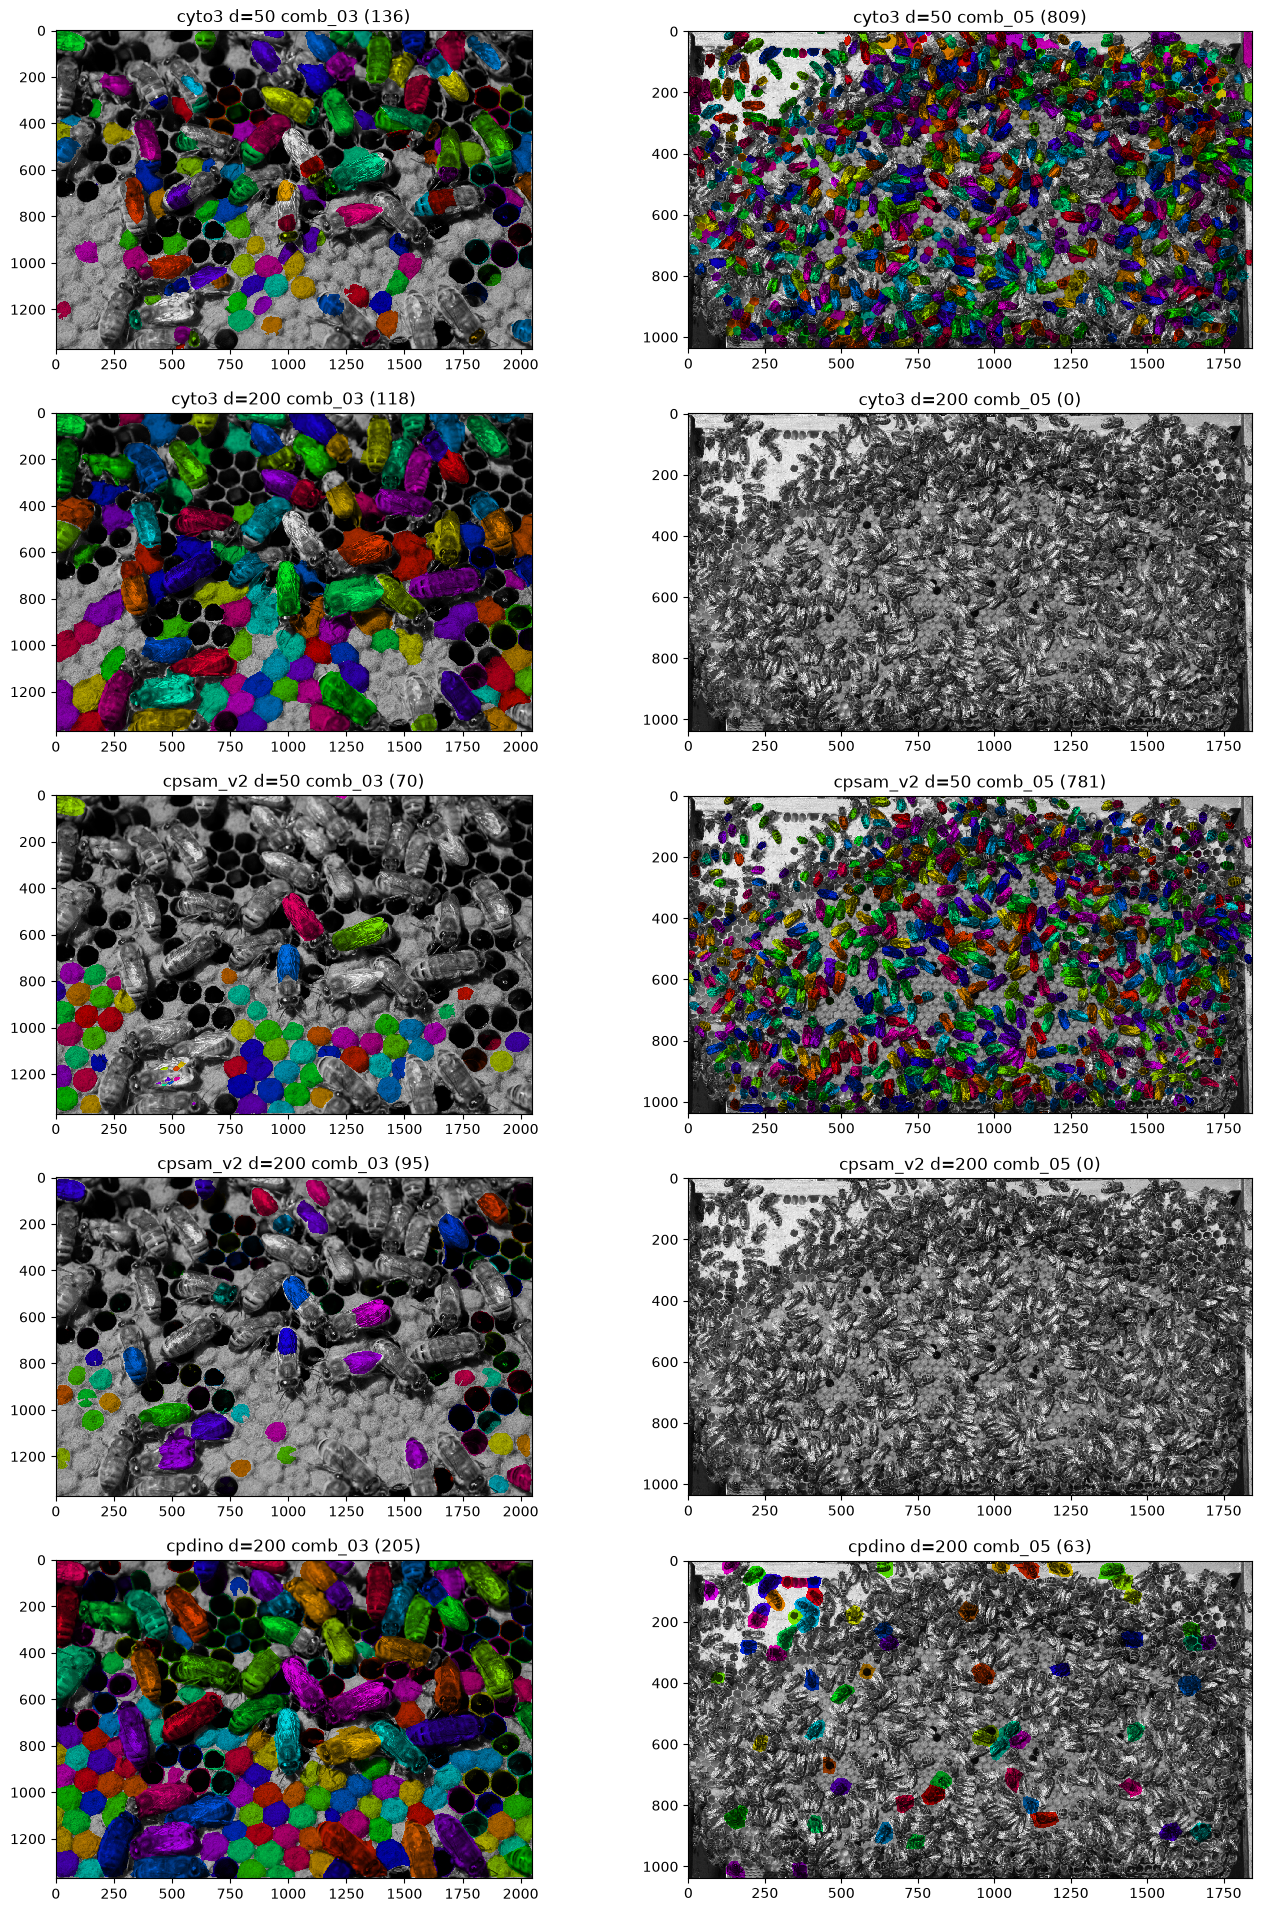

In [21]:
runs = [
    ('cyto3 d=50', cyto3_d50),
    ('cyto3 d=200', cyto3_d200),
    ('cpsam_v2 d=50', cpsam_d50),
    ('cpsam_v2 d=200', cpsam_d200),
    ('cpdino d=200', cpdino_d200),
]

# Cellpose's own way of showing this: image in grey, one colour per object.
overlays, titles = [], []
for label, result in runs:
    for name, im in images.items():
        r = result[name]
        overlays.append(mask_overlay(im, r))
        titles.append(f'{label} {name} ({r.max()})')

fig = imshow_multi2d(overlays, titles, len(runs), len(images), width=16, height=24)

## What to take from this

- None of these is good enough to count bees.
- Diameter moves Cellpose 3 a long way and Cellpose 4 hardly at all.
- Next: train on labelled patches and run the same comparison.